In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv(r'C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\drone_noise_assessment\values\drone_noise_results.csv')
print(df)

    RPM  Expected_BPF  H1_freq  H1_spl  H2_freq  H2_spl  H3_freq  H3_spl  \
0  2250         75.00    74.19   25.42   172.43   23.19   221.55   20.86   
1  2950         98.33    97.24   26.72   194.49   35.30   292.73   21.11   
2  3000        100.00    97.24   29.04   194.49   33.53   290.73   21.25   
3  3600        120.00   117.29   29.83   233.58   33.10   349.87   25.50   
4  4500        150.00   151.38   40.82   302.76   33.99   454.14   39.43   
5  5700        190.00   189.47   49.23   377.94   48.14   567.42   33.93   

   H2_reliable  H3_reliable  
0        False         True  
1         True         True  
2         True         True  
3         True         True  
4         True         True  
5         True         True  


In [2]:
loo = LeaveOneOut()

def evaluate_loo(X, y, label, verbose=True):
    preds = []
    actuals = []
    for train_idx, test_idx in loo.split(X):
        model = LinearRegression()
        model.fit(X[train_idx], y[train_idx])
        preds.append(model.predict(X[test_idx])[0])
        actuals.append(y[test_idx][0])
    mae = mean_absolute_error(actuals, preds)
    r2 = r2_score(actuals, preds)
    if verbose:
        print(f"{label}: MAE = {mae:.1f} RPM, R² = {r2:.3f}")
    return preds, actuals, mae, r2

In [3]:
X_h1 = df[['H1_freq', 'H1_spl']].values
y = df['RPM'].values

preds_h1, actuals_h1, mae_h1, r2_h1 = evaluate_loo(X_h1, y, "H1 only (fundamental)")

H1 only (fundamental): MAE = 57.3 RPM, R² = 0.997


In [4]:
X_h1h3 = df[['H1_freq', 'H1_spl', 'H3_freq', 'H3_spl']].values

preds_h1h3, actuals_h1h3, mae_h1h3, r2_h1h3 = evaluate_loo(X_h1h3, y, "H1 + H3 (4 features)")

H1 + H3 (4 features): MAE = 163.1 RPM, R² = 0.974


In [5]:
df_h2_reliable = df[df['H2_reliable'] == True].copy()

X_full = df_h2_reliable[['H1_freq', 'H1_spl', 'H2_freq', 'H2_spl', 'H3_freq', 'H3_spl']].values
y_full = df_h2_reliable['RPM'].values

preds_full, actuals_full, mae_full, r2_full = evaluate_loo(X_full, y_full, "H1 + H2 + H3 (6 features, 5 points)")

H1 + H2 + H3 (6 features, 5 points): MAE = 149.4 RPM, R² = 0.973


In [6]:
comparison = pd.DataFrame({
    'Model': ['H1 only', 'H1 + H3', 'H1 + H2 + H3'],
    'Features': [2, 4, 6],
    'N_points': [6, 6, 5],
    'MAE_RPM': [mae_h1, mae_h1h3, mae_full],
    'R2': [r2_h1, r2_h1h3, r2_full]
})
print(comparison)
comparison.to_csv(r'C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\drone_noise_assessment\values\model_comparison.csv', index=False)

          Model  Features  N_points     MAE_RPM        R2
0       H1 only         2         6   57.255886  0.997136
1       H1 + H3         4         6  163.117666  0.973881
2  H1 + H2 + H3         6         5  149.404470  0.973412


In [7]:
# Compare actual LOO predictions vs true RPM, model by model

comparison_detail = pd.DataFrame({
    'RPM_actual': y,  # true RPM for H1-only's 6 points
    'H1_predicted': preds_h1,
    'H1_error': np.array(preds_h1) - y,
})

print("=== H1 Only: Predicted vs Actual ===")
print(comparison_detail)
print()

comparison_detail_h3 = pd.DataFrame({
    'RPM_actual': y,
    'H1H3_predicted': preds_h1h3,
    'H1H3_error': np.array(preds_h1h3) - y,
})
print("=== H1+H3: Predicted vs Actual ===")
print(comparison_detail_h3)
print()

comparison_detail_full = pd.DataFrame({
    'RPM_actual': y_full,
    'H1H2H3_predicted': preds_full,
    'H1H2H3_error': np.array(preds_full) - y_full,
})
print("=== H1+H2+H3: Predicted vs Actual ===")
print(comparison_detail_full)

=== H1 Only: Predicted vs Actual ===
   RPM_actual  H1_predicted   H1_error
0        2250   2275.473867  25.473867
1        2950   2995.250500  45.250500
2        3000   2936.504740 -63.495260
3        3600   3554.321498 -45.678502
4        4500   4573.659367  73.659367
5        5700   5610.022179 -89.977821

=== H1+H3: Predicted vs Actual ===
   RPM_actual  H1H3_predicted  H1H3_error
0        2250     2311.476681   61.476681
1        2950     3176.395864  226.395864
2        3000     2961.103845  -38.896155
3        3600     3871.004483  271.004483
4        4500     4285.678014 -214.321986
5        5700     5866.610825  166.610825

=== H1+H2+H3: Predicted vs Actual ===
   RPM_actual  H1H2H3_predicted  H1H2H3_error
0        2950       3038.526206     88.526206
1        3000       2929.893741    -70.106259
2        3600       3503.623199    -96.376801
3        4500       4756.765069    256.765069
4        5700       5464.751984   -235.248016


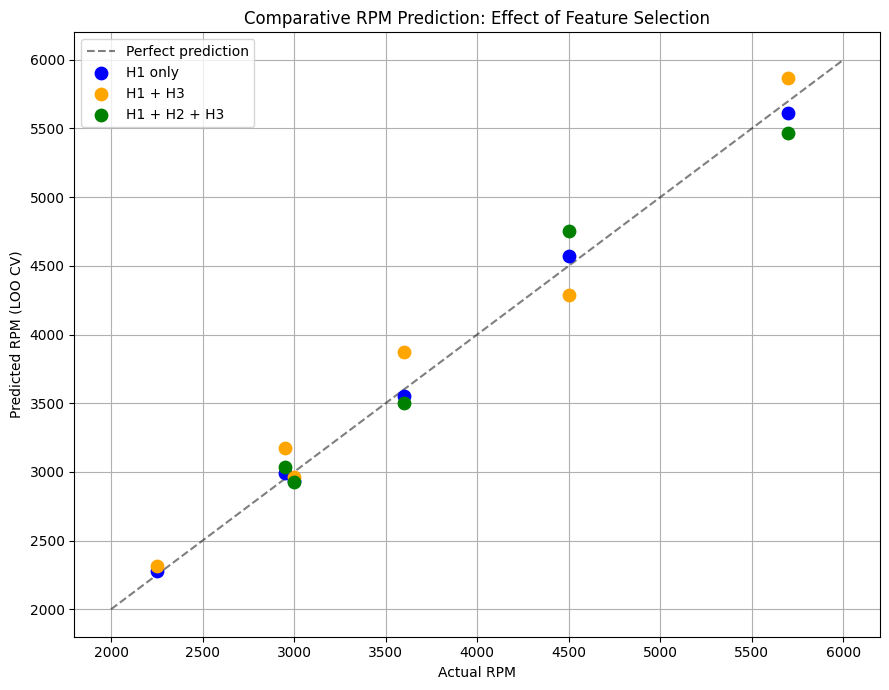

In [8]:
plt.figure(figsize=(9, 7))

plt.plot([2000, 6000], [2000, 6000], 'k--', alpha=0.5, label='Perfect prediction')

plt.scatter(y, preds_h1, color='blue', s=80, zorder=5, label='H1 only')
plt.scatter(y, preds_h1h3, color='orange', s=80, zorder=5, label='H1 + H3')
plt.scatter(y_full, preds_full, color='green', s=80, zorder=5, label='H1 + H2 + H3')

plt.xlabel('Actual RPM')
plt.ylabel('Predicted RPM (LOO CV)')
plt.title('Comparative RPM Prediction: Effect of Feature Selection')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150)
plt.show()

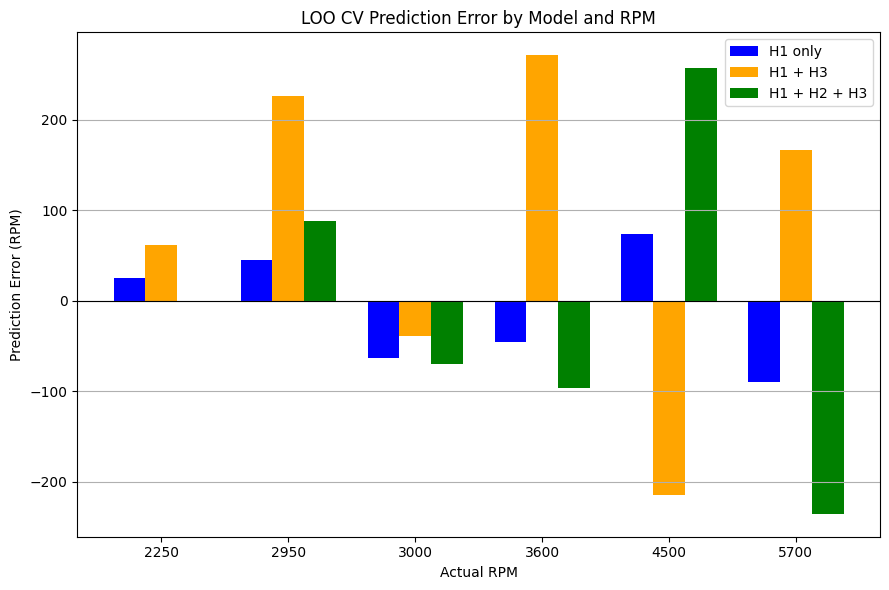

In [9]:
plt.figure(figsize=(9, 6))

x_pos = np.arange(len(y))
width = 0.25

errors_h1 = np.array(preds_h1) - y
errors_h1h3 = np.array(preds_h1h3) - y

plt.bar(x_pos - width, errors_h1, width, label='H1 only', color='blue')
plt.bar(x_pos, errors_h1h3, width, label='H1 + H3', color='orange')

# H1+H2+H3 only has 5 points (missing 2250), align carefully
rpm_full_list = list(y_full)
errors_full_aligned = []
for rpm_val in y:
    if rpm_val in rpm_full_list:
        idx = rpm_full_list.index(rpm_val)
        errors_full_aligned.append(preds_full[idx] - rpm_val)
    else:
        errors_full_aligned.append(np.nan)

plt.bar(x_pos + width, errors_full_aligned, width, label='H1 + H2 + H3', color='green')

plt.axhline(y=0, color='black', linewidth=0.8)
plt.xticks(x_pos, y.astype(int))
plt.xlabel('Actual RPM')
plt.ylabel('Prediction Error (RPM)')
plt.title('LOO CV Prediction Error by Model and RPM')
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig('fig_model_comparison_errors.png', dpi=150)
plt.show()

BPF coefficient: 31.869138184223516
SPL coefficient: -10.774938991938729
Intercept: 167.2668183406172


C:\Users\Isha Kulshrestha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


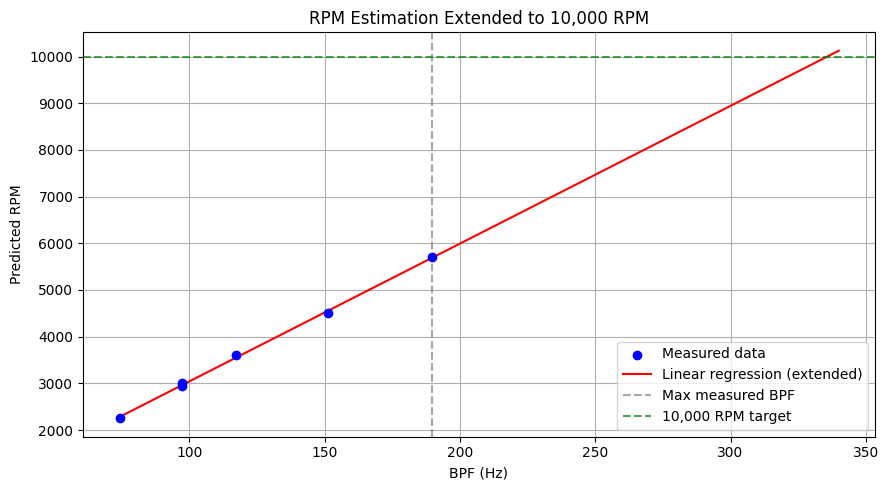

In [14]:
# Re-derive rpms and spls from current df (H1 only, since that's our best model)
rpms = df['RPM'].values
spls = df['H1_spl'].values

# BPF extrapolation (using H1-only linear regression, already validated as best model)
X_h1 = df[['H1_freq', 'H1_spl']].values
y = df['RPM'].values

lr_full = LinearRegression()
lr_full.fit(X_h1, y)

print("BPF coefficient:", lr_full.coef_[0])
print("SPL coefficient:", lr_full.coef_[1])
print("Intercept:", lr_full.intercept_)

# Fit SPL vs BPF relationship for generating extended feature set
lr_spl_vs_bpf = LinearRegression()
lr_spl_vs_bpf.fit(df[['H1_freq']], df['H1_spl'])

bpf_extended = np.linspace(74, 340, 100).reshape(-1, 1)
spl_extended = lr_spl_vs_bpf.predict(bpf_extended)
X_extended = np.column_stack([bpf_extended, spl_extended])
rpm_extended = lr_full.predict(X_extended)

plt.figure(figsize=(9, 5))
plt.scatter(df['H1_freq'], y, color='blue', zorder=5, label='Measured data')
plt.plot(bpf_extended, rpm_extended, 'r-', label='Linear regression (extended)')
plt.axvline(x=189.47, color='gray', linestyle='--', alpha=0.7, label='Max measured BPF')
plt.axhline(y=10000, color='green', linestyle='--', alpha=0.7, label='10,000 RPM target')
plt.xlabel('BPF (Hz)')
plt.ylabel('Predicted RPM')
plt.title('RPM Estimation Extended to 10,000 RPM')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('fig8_bpf_extrapolation.png', dpi=150)
plt.show()

Fitted parameters: a = 0.038840, b = 0.8244
Predicted SPL at 10,000 RPM: 77.05 dB
SPL power-law LOO CV: MAE = 2.56 dB, R² = 0.885


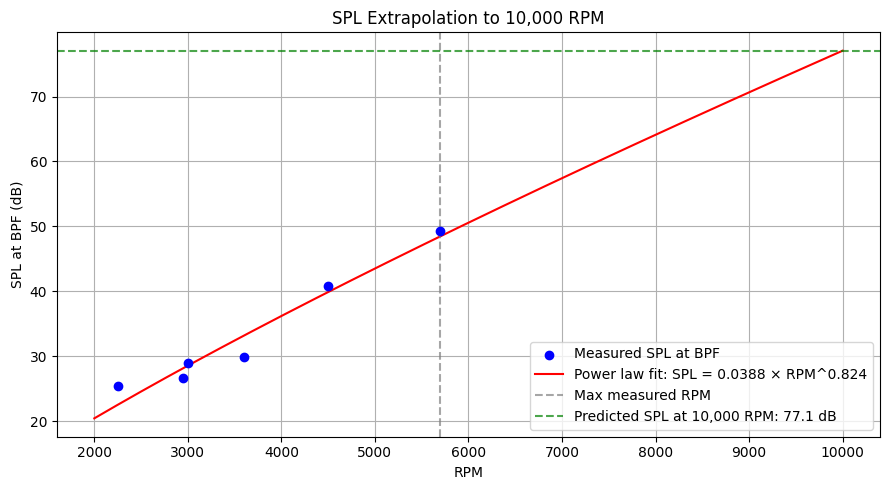

In [15]:
# SPL extrapolation with power law + LOO CV
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, r2_score

def power_law(rpm, a, b):
    return a * np.power(rpm, b)

popt, _ = curve_fit(power_law, rpms, spls, p0=[0.01, 1.5])
a, b = popt
print(f"Fitted parameters: a = {a:.6f}, b = {b:.4f}")
print(f"Predicted SPL at 10,000 RPM: {power_law(10000, a, b):.2f} dB")

# LOO CV for SPL power law
def evaluate_loo_curvefit(rpms, spls):
    preds, actuals = [], []
    for i in range(len(rpms)):
        train_rpm = np.delete(rpms, i)
        train_spl = np.delete(spls, i)
        popt_i, _ = curve_fit(power_law, train_rpm, train_spl, p0=[0.01, 1.5])
        preds.append(power_law(rpms[i], *popt_i))
        actuals.append(spls[i])
    mae = mean_absolute_error(actuals, preds)
    r2 = r2_score(actuals, preds)
    return preds, actuals, mae, r2

preds_spl, actuals_spl, mae_spl, r2_spl = evaluate_loo_curvefit(rpms, spls)
print(f"SPL power-law LOO CV: MAE = {mae_spl:.2f} dB, R² = {r2_spl:.3f}")

rpm_extended2 = np.linspace(2000, 10000, 500)
spl_extended2 = power_law(rpm_extended2, a, b)

plt.figure(figsize=(9, 5))
plt.scatter(rpms, spls, color='blue', zorder=5, label='Measured SPL at BPF')
plt.plot(rpm_extended2, spl_extended2, 'r-', label=f'Power law fit: SPL = {a:.4f} × RPM^{b:.3f}')
plt.axvline(x=5700, color='gray', linestyle='--', alpha=0.7, label='Max measured RPM')
plt.axhline(y=power_law(10000, a, b), color='green', linestyle='--',
            alpha=0.7, label=f'Predicted SPL at 10,000 RPM: {power_law(10000, a, b):.1f} dB')
plt.xlabel('RPM')
plt.ylabel('SPL at BPF (dB)')
plt.title('SPL Extrapolation to 10,000 RPM')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('fig9_spl_extrapolation.png', dpi=150)
plt.show()

In [9]:
# Extended RPM range
rpm_range = np.arange(2000, 10500, 500)

# BPF extrapolation (linear: BPF = RPM / 30)
bpf_extrapolated = rpm_range / 30

# SPL extrapolation (power law)
spl_extrapolated = power_law(rpm_range, a, b)

# Mark which values are measured vs extrapolated
measured_rpms = [2250, 2950, 3000, 3600, 4500, 5700]

df_extrap = pd.DataFrame({
    'RPM': rpm_range,
    'BPF_Hz': np.round(bpf_extrapolated, 2),
    'SPL_dB': np.round(spl_extrapolated, 2),
    'Data_Type': ['Measured' if rpm in measured_rpms else 'Extrapolated' for rpm in rpm_range]
})

print(df_extrap)
df_extrap.to_csv(r"C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\extrapolated_values\extrapolated_values.csv", index=False)
print("Saved to extrapolated_values.csv")

      RPM  BPF_Hz  SPL_dB     Data_Type
0    2000   66.67   20.44  Extrapolated
1    2500   83.33   24.57  Extrapolated
2    3000  100.00   28.56      Measured
3    3500  116.67   32.43  Extrapolated
4    4000  133.33   36.20  Extrapolated
5    4500  150.00   39.89      Measured
6    5000  166.67   43.51  Extrapolated
7    5500  183.33   47.07  Extrapolated
8    6000  200.00   50.57  Extrapolated
9    6500  216.67   54.02  Extrapolated
10   7000  233.33   57.42  Extrapolated
11   7500  250.00   60.78  Extrapolated
12   8000  266.67   64.11  Extrapolated
13   8500  283.33   67.39  Extrapolated
14   9000  300.00   70.64  Extrapolated
15   9500  316.67   73.86  Extrapolated
16  10000  333.33   77.05  Extrapolated
Saved to extrapolated_values.csv


In [16]:
def evaluate_loo_curvefit(rpms, spls):
    preds = []
    actuals = []
    for i in range(len(rpms)):
        train_rpm = np.delete(rpms, i)
        train_spl = np.delete(spls, i)
        test_rpm = rpms[i]
        test_spl = spls[i]
        
        popt, _ = curve_fit(power_law, train_rpm, train_spl, p0=[0.01, 1.5])
        pred = power_law(test_rpm, *popt)
        preds.append(pred)
        actuals.append(test_spl)
    
    mae = mean_absolute_error(actuals, preds)
    r2 = r2_score(actuals, preds)
    return preds, actuals, mae, r2

preds_spl, actuals_spl, mae_spl, r2_spl = evaluate_loo_curvefit(rpms, spls)
print(f"SPL power-law LOO CV: MAE = {mae_spl:.2f} dB, R² = {r2_spl:.3f}")

SPL power-law LOO CV: MAE = 2.56 dB, R² = 0.885
